# Japan Aviation Industry During Covid-19 Project - Alexander Aryasena 2025

Dataset: OpenSky Network flight records for 2020–2021, filtered to flights connected to Japan (ICAO prefix RJ/RO). About 380k flights total across the two years.

Using PySpark to handle the raw monthly CSVs (~50M rows combined) without needing to pre-merge them.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("JapanFlightAnalysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 23:12:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df2020 = spark.read.csv('flightdata/2020/*.csv', header=True, inferSchema=True)
print(f"2020 row count: {df2020.count()}")
df2020.show(5)

2020 row count: 22494526
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+-------------------+------------------+----------+------------------+------------------+-----------------+
|callsign|number|icao24|registration|typecode|origin|destination|          firstseen|           lastseen|                day|         latitude_1|       longitude_1|altitude_1|        latitude_2|       longitude_2|       altitude_2|
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+-------------------+------------------+----------+------------------+------------------+-----------------+
| SXI1963|  NULL|7c1ace|      VH-FKW|     F50|  YPAD|       WSSL|2019-12-31 09:07:07|2020-01-01 18:01:00|2020-01-01 09:00:00| -34.95975300417109| 138.4747123718262|     609.6|1.3885345458984382|103.84919764631891|           182.88|
|  THY183|  NULL|4ba9c1|      TC-JNA|    A332| 

In [3]:
df2021 = spark.read.csv('flightdata/2021/*.csv', header=True, inferSchema=True)
print(f"2021 row count: {df2021.count()}")
df2021.show(5)

2021 row count: 28643583
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+------------------+------------------+----------+-----------------+------------------+-----------------+
|callsign|number|icao24|registration|typecode|origin|destination|          firstseen|           lastseen|                day|        latitude_1|       longitude_1|altitude_1|       latitude_2|       longitude_2|       altitude_2|
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+------------------+------------------+----------+-----------------+------------------+-----------------+
| AHO9687|  NULL|3c08c9|        NULL|    NULL|  YSSY|       NULL|2020-12-31 09:22:04|2021-01-01 23:51:39|2021-01-01 09:00:00|-33.95534192101434| 151.1781120300293|       0.0|43.18840026855469| 8.402049929596657|7376.160000000001|
|  ETH726|  NULL|040103|      ET-ASI|    B788|  KJFK|  

In [4]:
# RJ/RO = ICAO prefixes for Japan airports
japan_prefixes = ['RJ', 'RO']
df2020japan = df2020.filter(
    (F.substring(F.col('origin'), 1, 2).isin(japan_prefixes)) |
    (F.substring(F.col('destination'), 1, 2).isin(japan_prefixes))
).dropna(subset=['origin', 'destination'])
print(f"2020 Japan rows: {df2020japan.count()}")
df2020japan.show(5)

2020 Japan rows: 146563
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+------------------+------------------+----------+------------------+-------------------+----------+
|callsign|number|icao24|registration|typecode|origin|destination|          firstseen|           lastseen|                day|        latitude_1|       longitude_1|altitude_1|        latitude_2|        longitude_2|altitude_2|
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+------------------+------------------+----------+------------------+-------------------+----------+
|  CCA847|  NULL|781641|      B-307A|    A359|  RJBB|       EGKK|2019-12-31 13:43:59|2020-01-01 15:01:26|2020-01-01 09:00:00| 34.42501831054688| 135.2408023756378|    -304.8|51.139960854740465|-0.2497100830078125|     114.3|
| CES2051|  NULL|79a04b|      B-6001|    A320|  WSSS|       RJBB|2019-12-31 

In [5]:
df2021japan = df2021.filter(
    (F.substring(F.col('origin'), 1, 2).isin(japan_prefixes)) |
    (F.substring(F.col('destination'), 1, 2).isin(japan_prefixes))
).dropna(subset=['origin', 'destination'])
print(f"2021 Japan rows: {df2021japan.count()}")
df2021japan.show(5)

2021 Japan rows: 232913
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+-----------------+-----------------+----------+-----------------+-----------------+----------+
|callsign|number|icao24|registration|typecode|origin|destination|          firstseen|           lastseen|                day|       latitude_1|      longitude_1|altitude_1|       latitude_2|      longitude_2|altitude_2|
+--------+------+------+------------+--------+------+-----------+-------------------+-------------------+-------------------+-----------------+-----------------+----------+-----------------+-----------------+----------+
|  QTR807|  NULL|06a121|        NULL|    NULL|  RJAA|       OTHH|2020-12-31 22:40:37|2021-01-01 11:03:51|2021-01-01 09:00:00|35.82362288135593|140.3326351084608|     914.4|25.24928283691406|51.62953694661459|     22.86|
|  KLM861| KL861|4851ad|      PH-BHA|    B789|  EHAM|       RJAA|2020-12-31 22:46:50|2021-01-01 

In [6]:
cols_to_drop = ['icao24', 'firstseen', 'lastseen',
                'latitude_1', 'longitude_1', 'altitude_1',
                'latitude_2', 'longitude_2', 'altitude_2']

dfjapan2 = df2020japan.union(df2021japan) \
    .drop(*cols_to_drop) \
    .withColumn('day', F.col('day').cast('date')) \
    .withColumn('Callsign Prefix', F.substring('callsign', 1, 3))

dfjapan2.cache()
print(f"Total Japan rows: {dfjapan2.count()}")
dfjapan2.show(5)

Total Japan rows: 379476
+--------+------+------------+--------+------+-----------+----------+---------------+
|callsign|number|registration|typecode|origin|destination|       day|Callsign Prefix|
+--------+------+------------+--------+------+-----------+----------+---------------+
|  CCA847|  NULL|      B-307A|    A359|  RJBB|       EGKK|2020-01-01|            CCA|
| CES2051|  NULL|      B-6001|    A320|  WSSS|       RJBB|2020-01-01|            CES|
| CSN8307|  NULL|      B-5041|    B738|  VTBS|       RJBB|2020-01-01|            CSN|
|  KLM867| KL867|      PH-BHL|    B789|  EHAM|       RJBB|2020-01-01|            KLM|
|  UAE317| EK317|      A6-EDA|    A388|  RJBB|       OMDB|2020-01-01|            UAE|
+--------+------+------------+--------+------+-----------+----------+---------------+
only showing top 5 rows


In [7]:
# Monthly flight counts with month-over-month % change
w_month = Window.orderBy('YearMonth')

monthly_flights = dfjapan2 \
    .withColumn('YearMonth', F.date_format('day', 'yyyy-MM')) \
    .groupBy('YearMonth').count() \
    .withColumnRenamed('count', 'Total_Flights') \
    .orderBy('YearMonth') \
    .withColumn(
        'Pct_Change_Month',
        (F.col('Total_Flights') - F.lag('Total_Flights', 1).over(w_month))
        / F.lag('Total_Flights', 1).over(w_month) * 100
    )

monthly_flights.show(30)

+---------+-------------+-------------------+
|YearMonth|Total_Flights|   Pct_Change_Month|
+---------+-------------+-------------------+
|  2020-01|        20269|               NULL|
|  2020-02|        19386| -4.356406334796981|
|  2020-03|        13070|-32.580212524502215|
|  2020-04|         6245| -52.21882172915072|
|  2020-05|         4794|-23.234587670136108|
|  2020-06|         7287|  52.00250312891114|
|  2020-07|        10366|  42.25332784410594|
|  2020-08|        12135| 17.065406135442792|
|  2020-09|        10487| -13.58055212196127|
|  2020-10|        11366|  8.381806045580243|
|  2020-11|        13841| 21.775470702093962|
|  2020-12|        17317|  25.11379235604364|
|  2021-01|        12234|-29.352659236588323|
|  2021-02|        11073| -9.489946051986268|
|  2021-03|        16575|  49.68843131942563|
|  2021-04|        18822| 13.556561085972852|
|  2021-05|        18025| -4.234406545531824|
|  2021-06|        18846|  4.554785020804438|
|  2021-07|        20893| 10.86172

April 2020 is the sharpest drop — down 52% from March, right when the first emergency declaration hit. The recovery from June onward is slow and uneven, never really getting back to Jan 2020 levels until mid-2021.

In [ ]:
# Yearly flight counts with yoy % change
w_year = Window.orderBy('Year')

yearly_flights = dfjapan2 \
    .withColumn('Year', F.year('day')) \
    .groupBy('Year').count() \
    .withColumnRenamed('count', 'Total_Flights') \
    .orderBy('Year') \
    .withColumn(
        'Pct_Change_Year',
        (F.col('Total_Flights') - F.lag('Total_Flights', 1).over(w_year))
        / F.lag('Total_Flights', 1).over(w_year) * 100
    )

yearly_flights.show()

+----+-------------+-----------------+
|Year|Total_Flights|  Pct_Change_Year|
+----+-------------+-----------------+
|2020|       146563|             NULL|
|2021|       232913|58.91664335473482|
+----+-------------+-----------------+



2021 is up ~59% vs 2020, but that's a bit misleading since 2020 had a normal January/February before things collapsed. The monthly breakdown tells a clearer story.

In [9]:
# Find the least busiest day
daily_flight_counts = dfjapan2.groupBy('day').count() \
    .withColumnRenamed('count', 'Total_Flights')

min_flights = daily_flight_counts.agg(F.min('Total_Flights')).collect()[0][0]
least_busiest_day = daily_flight_counts.filter(F.col('Total_Flights') == min_flights)
least_busiest_day.show()

+----------+-------------+
|       day|Total_Flights|
+----------+-------------+
|2020-05-04|          117|
+----------+-------------+



May 4, 2020 — right in the middle of Golden Week under the first state of emergency. 117 flights total. For context, a normal day in January 2020 was averaging 650+.

In [10]:
# All-airport flight counts (origin + destination pooled)
airports_in  = dfjapan2.select(F.col('origin').alias('Airport'))
airports_out = dfjapan2.select(F.col('destination').alias('Airport'))

airport_flights = airports_in.union(airports_out) \
    .groupBy('Airport').count() \
    .withColumnRenamed('count', 'Total_Flights') \
    .orderBy('Airport')

airport_flights.show()
airport_flights.toPandas().to_csv('airport_flights.csv', index=False)

+-------+-------------+
|Airport|Total_Flights|
+-------+-------------+
|   05IN|           23|
|   0TS2|            2|
|   0TX7|            1|
|   13CL|           46|
|   14AR|            2|
|   15AR|           10|
|   17IN|            7|
|   1TE2|           26|
|   1XS1|           77|
|   20KY|            1|
|   20SC|            1|
|   27CL|            4|
|   31II|           11|
|   32II|           17|
|   35MN|            5|
|   36II|            2|
|   38IN|            2|
|   3KY4|            6|
|   3TX2|            1|
|   3XS8|            1|
+-------+-------------+
only showing top 20 rows


In [11]:
dfjapan2.toPandas().to_csv('dfjapan.csv', index=False)

# Inbound Japan (International Flights)

### By Airport

In [12]:
# Inbound: flights arriving in Japan from abroad (origin does NOT start with RJ/RO)
dfjapan2_inbound = dfjapan2.filter(
    ~F.substring(F.col('origin'), 1, 2).isin(japan_prefixes)
)
print(f"Inbound rows: {dfjapan2_inbound.count()}")
dfjapan2_inbound.show(5)

Inbound rows: 73830
+--------+------+------------+--------+------+-----------+----------+---------------+
|callsign|number|registration|typecode|origin|destination|       day|Callsign Prefix|
+--------+------+------------+--------+------+-----------+----------+---------------+
| CES2051|  NULL|      B-6001|    A320|  WSSS|       RJBB|2020-01-01|            CES|
| CSN8307|  NULL|      B-5041|    B738|  VTBS|       RJBB|2020-01-01|            CSN|
|  KLM867| KL867|      PH-BHL|    B789|  EHAM|       RJBB|2020-01-01|            KLM|
|  AFR272| AF272|      F-GSQG|    B77W|  LFPG|       RJTK|2020-01-01|            AFR|
|   FIN77|  NULL|      OH-LWN|    A359|  EFHK|       RJBB|2020-01-01|            FIN|
+--------+------+------------+--------+------+-----------+----------+---------------+
only showing top 5 rows


In [13]:
dfjapan3_inbound_resample = dfjapan2_inbound.groupBy(
    'destination',
    F.date_format('day', 'yyyy-MM').alias('YearMonth')
).count().orderBy('destination', 'YearMonth')

dfjapan3_inbound_resample.cache()
dfjapan3_inbound_resample.show(10)

+-----------+---------+-----+
|destination|YearMonth|count|
+-----------+---------+-----+
|       RJAA|  2020-01|  255|
|       RJAA|  2020-02|  313|
|       RJAA|  2020-03|  236|
|       RJAA|  2020-04|  128|
|       RJAA|  2020-05|  178|
|       RJAA|  2020-06|  204|
|       RJAA|  2020-07|  252|
|       RJAA|  2020-08|  298|
|       RJAA|  2020-09|  155|
|       RJAA|  2020-10|   74|
+-----------+---------+-----+
only showing top 10 rows


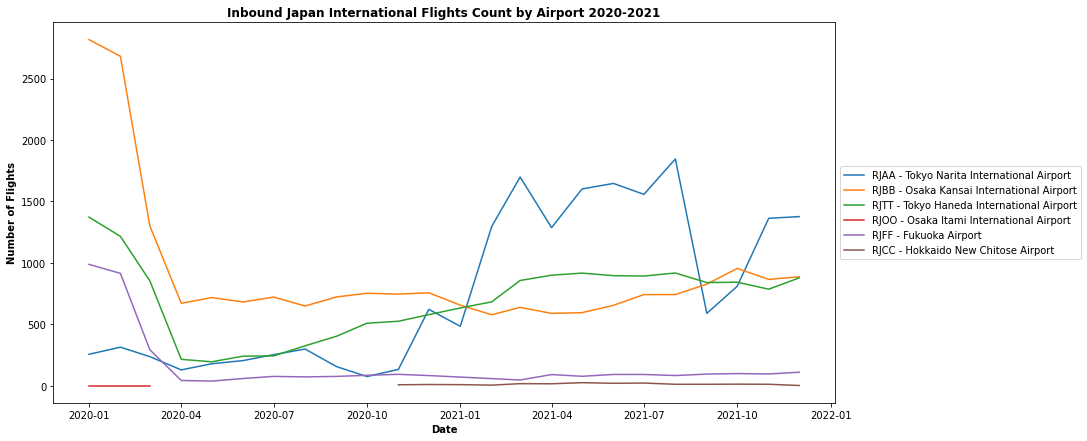

In [14]:
def get_inbound_airport(airport_code):
    df = dfjapan3_inbound_resample \
        .filter(F.col('destination') == airport_code) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_rjaa = get_inbound_airport('RJAA')
df_rjbb = get_inbound_airport('RJBB')
df_rjtt = get_inbound_airport('RJTT')
df_rjff = get_inbound_airport('RJFF')
df_rjoo = get_inbound_airport('RJOO')
df_rjcc = get_inbound_airport('RJCC')

plt.figure(figsize=(14, 7))
plt.plot(df_rjaa['YearMonth'], df_rjaa['count'], label='RJAA - Tokyo Narita International Airport')
plt.plot(df_rjbb['YearMonth'], df_rjbb['count'], label='RJBB - Osaka Kansai International Airport')
plt.plot(df_rjtt['YearMonth'], df_rjtt['count'], label='RJTT - Tokyo Haneda International Airport')
plt.plot(df_rjoo['YearMonth'], df_rjoo['count'], label='RJOO - Osaka Itami International Airport')
plt.plot(df_rjff['YearMonth'], df_rjff['count'], label='RJFF - Fukuoka Airport')
plt.plot(df_rjcc['YearMonth'], df_rjcc['count'], label='RJCC - Hokkaido New Chitose Airport')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Inbound Japan International Flights Count by Airport 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### By Japanese Airlines

In [15]:
dfjapan4_inbound_resample = dfjapan2_inbound \
    .withColumn('callsign_prefix', F.substring('callsign', 1, 3)) \
    .groupBy('callsign_prefix', F.date_format('day', 'yyyy-MM').alias('YearMonth')) \
    .count() \
    .orderBy('callsign_prefix', 'YearMonth')

dfjapan4_inbound_resample.cache()

DataFrame[callsign_prefix: string, YearMonth: string, count: bigint]

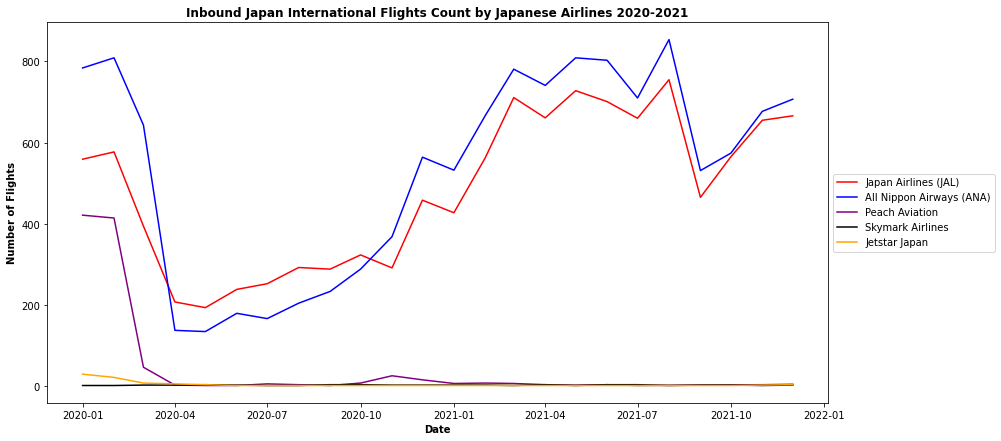

In [16]:
def get_inbound_airline(prefix):
    df = dfjapan4_inbound_resample \
        .filter(F.col('callsign_prefix') == prefix) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_jal = get_inbound_airline('JAL')
df_ana = get_inbound_airline('ANA')
df_apj = get_inbound_airline('APJ')
df_sky = get_inbound_airline('SKY')
df_jjp = get_inbound_airline('JJP')

plt.figure(figsize=(14, 7))
plt.plot(df_jal['YearMonth'], df_jal['count'], color='red',    label='Japan Airlines (JAL)')
plt.plot(df_ana['YearMonth'], df_ana['count'], color='blue',   label='All Nippon Airways (ANA)')
plt.plot(df_apj['YearMonth'], df_apj['count'], color='purple', label='Peach Aviation')
plt.plot(df_sky['YearMonth'], df_sky['count'], color='black',  label='Skymark Airlines')
plt.plot(df_jjp['YearMonth'], df_jjp['count'], color='orange', label='Jetstar Japan')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Inbound Japan International Flights Count by Japanese Airlines 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Outbound Japan (International Flights)

### By Airport

In [17]:
# Outbound: flights departing Japan to abroad (destination does NOT start with RJ/RO)
dfjapan2_outbound = dfjapan2.filter(
    ~F.substring(F.col('destination'), 1, 2).isin(japan_prefixes)
)
print(f"Outbound rows: {dfjapan2_outbound.count()}")
dfjapan2_outbound.show(5)

Outbound rows: 77554
+--------+------+------------+--------+------+-----------+----------+---------------+
|callsign|number|registration|typecode|origin|destination|       day|Callsign Prefix|
+--------+------+------------+--------+------+-----------+----------+---------------+
|  CCA847|  NULL|      B-307A|    A359|  RJBB|       EGKK|2020-01-01|            CCA|
|  UAE317| EK317|      A6-EDA|    A388|  RJBB|       OMDB|2020-01-01|            UAE|
|   FDX28|  NULL|      N883FD|    B77L|  RJBB|       KUTA|2020-01-01|            FDX|
|  CAL223| CI223|     B-18302|    A333|  RJTT|       RCSS|2020-01-01|            CAL|
|  APJ001|  NULL|      JA809P|    A320|  RJBB|       RKSI|2020-01-01|            APJ|
+--------+------+------------+--------+------+-----------+----------+---------------+
only showing top 5 rows


In [18]:
dfjapan3_outbound_resample = dfjapan2_outbound.groupBy(
    'origin',
    F.date_format('day', 'yyyy-MM').alias('YearMonth')
).count().orderBy('origin', 'YearMonth')

dfjapan3_outbound_resample.cache()
dfjapan3_outbound_resample.show(10)

+------+---------+-----+
|origin|YearMonth|count|
+------+---------+-----+
|  RJAA|  2020-01|    3|
|  RJAA|  2020-02|   26|
|  RJAA|  2020-03|   17|
|  RJAA|  2020-04|    2|
|  RJAA|  2020-05|    7|
|  RJAA|  2020-06|    9|
|  RJAA|  2020-07|   45|
|  RJAA|  2020-08|    9|
|  RJAA|  2020-09|   10|
|  RJAA|  2020-11|   17|
+------+---------+-----+
only showing top 10 rows


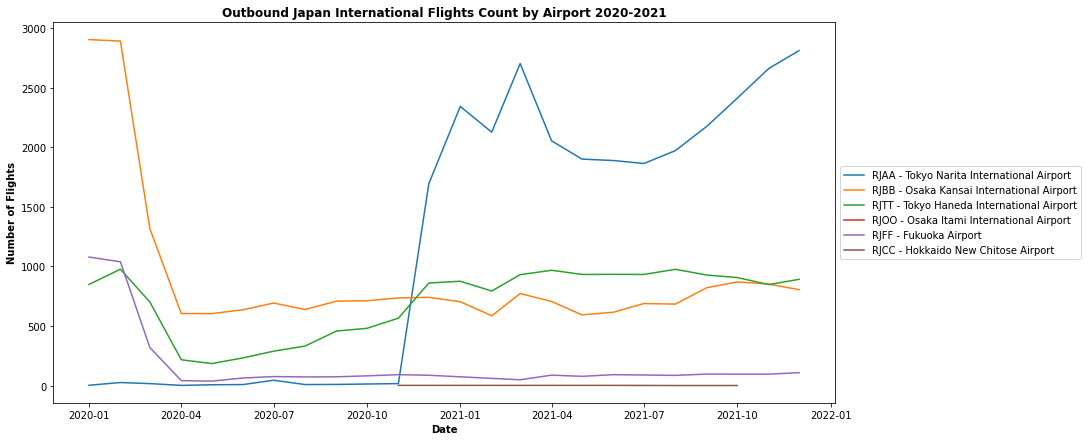

In [19]:
def get_outbound_airport(airport_code):
    df = dfjapan3_outbound_resample \
        .filter(F.col('origin') == airport_code) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_rjaa_out = get_outbound_airport('RJAA')
df_rjbb_out = get_outbound_airport('RJBB')
df_rjtt_out = get_outbound_airport('RJTT')
df_rjff_out = get_outbound_airport('RJFF')
df_rjoo_out = get_outbound_airport('RJOO')
df_rjcc_out = get_outbound_airport('RJCC')

plt.figure(figsize=(14, 7))
plt.plot(df_rjaa_out['YearMonth'], df_rjaa_out['count'], label='RJAA - Tokyo Narita International Airport')
plt.plot(df_rjbb_out['YearMonth'], df_rjbb_out['count'], label='RJBB - Osaka Kansai International Airport')
plt.plot(df_rjtt_out['YearMonth'], df_rjtt_out['count'], label='RJTT - Tokyo Haneda International Airport')
plt.plot(df_rjoo_out['YearMonth'], df_rjoo_out['count'], label='RJOO - Osaka Itami International Airport')
plt.plot(df_rjff_out['YearMonth'], df_rjff_out['count'], label='RJFF - Fukuoka Airport')
plt.plot(df_rjcc_out['YearMonth'], df_rjcc_out['count'], label='RJCC - Hokkaido New Chitose Airport')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Outbound Japan International Flights Count by Airport 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### By Airlines

In [20]:
dfjapan4_outbound_resample = dfjapan2_outbound \
    .withColumn('callsign_prefix', F.substring('callsign', 1, 3)) \
    .groupBy('callsign_prefix', F.date_format('day', 'yyyy-MM').alias('YearMonth')) \
    .count() \
    .orderBy('callsign_prefix', 'YearMonth')

dfjapan4_outbound_resample.cache()

DataFrame[callsign_prefix: string, YearMonth: string, count: bigint]

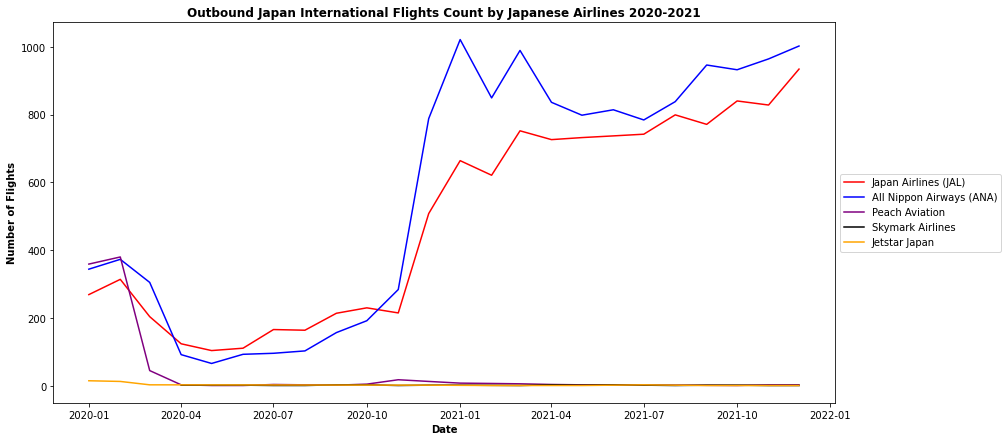

In [21]:
def get_outbound_airline(prefix):
    df = dfjapan4_outbound_resample \
        .filter(F.col('callsign_prefix') == prefix) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_jal_out = get_outbound_airline('JAL')
df_ana_out = get_outbound_airline('ANA')
df_apj_out = get_outbound_airline('APJ')
df_sky_out = get_outbound_airline('SKY')
df_jjp_out = get_outbound_airline('JJP')

plt.figure(figsize=(14, 7))
plt.plot(df_jal_out['YearMonth'], df_jal_out['count'], color='red',    label='Japan Airlines (JAL)')
plt.plot(df_ana_out['YearMonth'], df_ana_out['count'], color='blue',   label='All Nippon Airways (ANA)')
plt.plot(df_apj_out['YearMonth'], df_apj_out['count'], color='purple', label='Peach Aviation')
plt.plot(df_sky_out['YearMonth'], df_sky_out['count'], color='black',  label='Skymark Airlines')
plt.plot(df_jjp_out['YearMonth'], df_jjp_out['count'], color='orange', label='Jetstar Japan')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Outbound Japan International Flights Count by Japanese Airlines 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Domestic Flights

### By Airports

In [22]:
# Domestic: both origin AND destination start with RJ/RO
dfjapan2_domestic = dfjapan2.filter(
    F.substring(F.col('origin'), 1, 2).isin(japan_prefixes) &
    F.substring(F.col('destination'), 1, 2).isin(japan_prefixes)
)
print(f"Domestic rows: {dfjapan2_domestic.count()}")
dfjapan2_domestic.show(5)

Domestic rows: 228092
+--------+------+------------+--------+------+-----------+----------+---------------+
|callsign|number|registration|typecode|origin|destination|       day|Callsign Prefix|
+--------+------+------------+--------+------+-----------+----------+---------------+
|  SKY003|  NULL|      JA73NR|    B738|  RJTK|       RJFF|2020-01-01|            SKY|
|  JAL475|  NULL|      JA306J|    B738|  RJTK|       RJOT|2020-01-01|            JAL|
|  ANA242| NH242|      JA756A|    B773|  RJFF|       RJTK|2020-01-01|            ANA|
|  ANA421| NH421|      JA616A|    B763|  RJOO|       RJFF|2020-01-01|            ANA|
| ANA1702|NH1702|      JA219A|    A20N|  RJFF|       RJBB|2020-01-01|            ANA|
+--------+------+------------+--------+------+-----------+----------+---------------+
only showing top 5 rows


In [23]:
# Compute arrivals and departures per airport per month, then sum for total traffic
dom_arrivals = dfjapan2_domestic.groupBy(
    F.col('destination').alias('airport'),
    F.date_format('day', 'yyyy-MM').alias('YearMonth')
).count().withColumnRenamed('count', 'arrivals')

dom_departures = dfjapan2_domestic.groupBy(
    F.col('origin').alias('airport'),
    F.date_format('day', 'yyyy-MM').alias('YearMonth')
).count().withColumnRenamed('count', 'departures')

dom_traffic = dom_arrivals.join(dom_departures, ['airport', 'YearMonth'], 'outer') \
    .fillna(0) \
    .withColumn('Total', F.col('arrivals') + F.col('departures')) \
    .orderBy('airport', 'YearMonth')

dom_traffic.cache()
dom_traffic.show(10)

+-------+---------+--------+----------+-----+
|airport|YearMonth|arrivals|departures|Total|
+-------+---------+--------+----------+-----+
|   RJ04|  2020-11|       1|         0|    1|
|   RJ04|  2021-04|       1|         0|    1|
|   RJ04|  2021-05|       1|         0|    1|
|   RJ04|  2021-07|       0|         1|    1|
|   RJ04|  2021-10|       8|         0|    8|
|   RJ04|  2021-11|      17|         0|   17|
|   RJ04|  2021-12|      12|         0|   12|
|   RJAA|  2020-01|     103|        12|  115|
|   RJAA|  2020-02|     138|        28|  166|
|   RJAA|  2020-03|     178|        34|  212|
+-------+---------+--------+----------+-----+
only showing top 10 rows


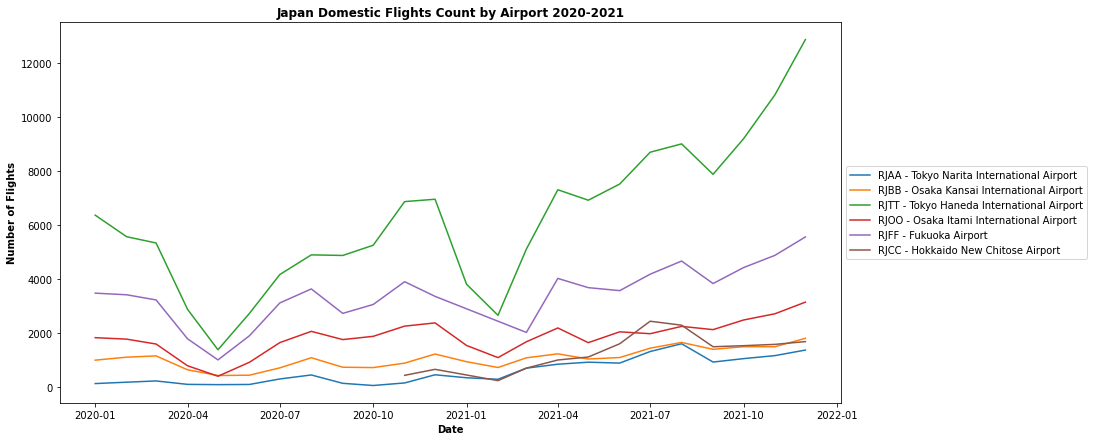

In [24]:
def get_dom_airport(airport_code):
    df = dom_traffic \
        .filter(F.col('airport') == airport_code) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_rjaa_dom = get_dom_airport('RJAA')
df_rjbb_dom = get_dom_airport('RJBB')
df_rjtt_dom = get_dom_airport('RJTT')
df_rjff_dom = get_dom_airport('RJFF')
df_rjoo_dom = get_dom_airport('RJOO')
df_rjcc_dom = get_dom_airport('RJCC')

plt.figure(figsize=(14, 7))
plt.plot(df_rjaa_dom['YearMonth'], df_rjaa_dom['Total'], label='RJAA - Tokyo Narita International Airport')
plt.plot(df_rjbb_dom['YearMonth'], df_rjbb_dom['Total'], label='RJBB - Osaka Kansai International Airport')
plt.plot(df_rjtt_dom['YearMonth'], df_rjtt_dom['Total'], label='RJTT - Tokyo Haneda International Airport')
plt.plot(df_rjoo_dom['YearMonth'], df_rjoo_dom['Total'], label='RJOO - Osaka Itami International Airport')
plt.plot(df_rjff_dom['YearMonth'], df_rjff_dom['Total'], label='RJFF - Fukuoka Airport')
plt.plot(df_rjcc_dom['YearMonth'], df_rjcc_dom['Total'], label='RJCC - Hokkaido New Chitose Airport')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Japan Domestic Flights Count by Airport 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

### By Airlines

In [25]:
dfjapan3_domestic_resample = dfjapan2_domestic \
    .withColumn('callsign_prefix', F.substring('callsign', 1, 3)) \
    .groupBy('callsign_prefix', F.date_format('day', 'yyyy-MM').alias('YearMonth')) \
    .count() \
    .orderBy('callsign_prefix', 'YearMonth')

dfjapan3_domestic_resample.cache()

DataFrame[callsign_prefix: string, YearMonth: string, count: bigint]

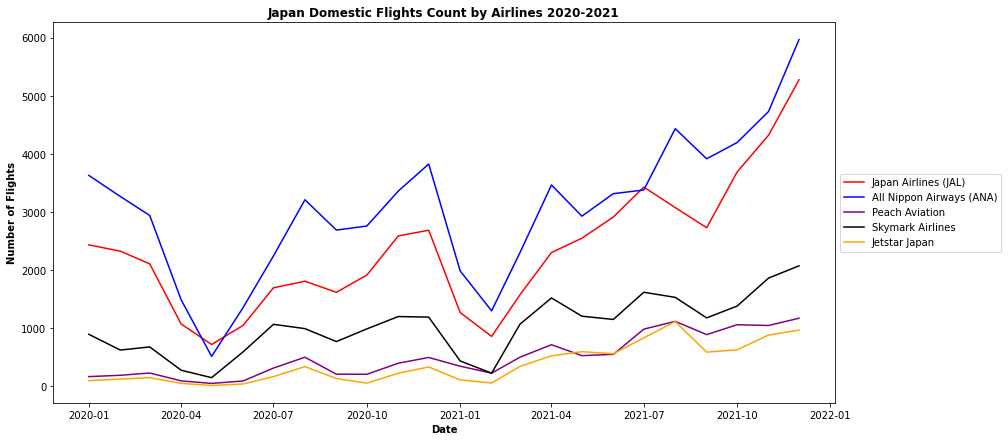

In [26]:
def get_dom_airline(prefix):
    df = dfjapan3_domestic_resample \
        .filter(F.col('callsign_prefix') == prefix) \
        .toPandas()
    df['YearMonth'] = pd.to_datetime(df['YearMonth'])
    return df.sort_values('YearMonth')

df_jal_dom = get_dom_airline('JAL')
df_ana_dom = get_dom_airline('ANA')
df_apj_dom = get_dom_airline('APJ')
df_sky_dom = get_dom_airline('SKY')
df_jjp_dom = get_dom_airline('JJP')

plt.figure(figsize=(14, 7))
plt.plot(df_jal_dom['YearMonth'], df_jal_dom['count'], color='red',    label='Japan Airlines (JAL)')
plt.plot(df_ana_dom['YearMonth'], df_ana_dom['count'], color='blue',   label='All Nippon Airways (ANA)')
plt.plot(df_apj_dom['YearMonth'], df_apj_dom['count'], color='purple', label='Peach Aviation')
plt.plot(df_sky_dom['YearMonth'], df_sky_dom['count'], color='black',  label='Skymark Airlines')
plt.plot(df_jjp_dom['YearMonth'], df_jjp_dom['count'], color='orange', label='Jetstar Japan')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')
plt.title('Japan Domestic Flights Count by Airlines 2020-2021', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# Covid-19 Data

In [27]:
df_covid19 = pd.read_csv('newly_confirmed_cases_daily.csv')
df_covid19['Date'] = pd.to_datetime(df_covid19['Date'])

df_covid19_new = df_covid19[
    (df_covid19['Date'] >= '2020-01-16') &
    (df_covid19['Date'] <= '2021-12-31')
].copy()

df_covid19_new.to_csv('df_covid19_japan.csv', index=False)
df_covid19_new

,Date,ALL,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
0,2020-01-16,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-01-17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020-01-18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2020-01-19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2020-01-20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2021-12-27,132,12,0,1,0,0,0,1,0,...,0,0,4,0,0,0,0,0,0,5
712,2021-12-28,347,23,0,0,0,0,0,1,2,...,0,0,6,0,1,0,0,0,0,30
713,2021-12-29,447,23,0,0,2,0,1,3,4,...,1,0,9,3,0,0,0,0,0,27
714,2021-12-30,435,35,0,4,0,0,0,0,1,...,0,0,3,1,0,0,0,0,4,47


## All Flights vs. Covid-19 Cases

In [28]:
flight_count = dfjapan2.groupBy('day').count() \
    .withColumnRenamed('count', 'callsign') \
    .orderBy('day') \
    .toPandas()
flight_count['day'] = pd.to_datetime(flight_count['day'])
flight_count

,day,callsign
0,2020-01-01,717
1,2020-01-02,680
2,2020-01-03,609
3,2020-01-04,732
4,2020-01-05,730
...,...,...
723,2021-12-27,820
724,2021-12-28,847
725,2021-12-29,1023
726,2021-12-30,853


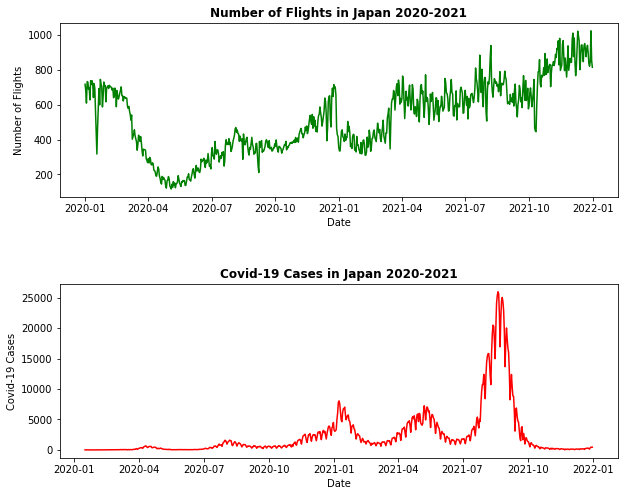

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(flight_count['day'], flight_count['callsign'], color='green')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Flights')
ax1.set_title('Number of Flights in Japan 2020-2021', fontweight='bold')

ax2.plot(df_covid19_new['Date'], df_covid19_new['ALL'], color='red')
ax2.set_xlabel('Date')
ax2.set_ylabel('Covid-19 Cases')
ax2.set_title('Covid-19 Cases in Japan 2020-2021', fontweight='bold')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [30]:
covid_indexed = df_covid19_new.set_index('Date')[['ALL']]
flights_indexed = flight_count.set_index('day')
dfcombine = flights_indexed.join(covid_indexed).dropna()
print(dfcombine.corr())

          callsign       ALL
callsign  1.000000  0.267896
ALL       0.267896  1.000000


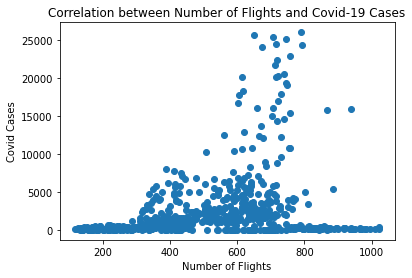

In [31]:
plt.scatter(dfcombine['callsign'], dfcombine['ALL'])
plt.xlabel('Number of Flights')
plt.ylabel('Covid Cases')
plt.title('Correlation between Number of Flights and Covid-19 Cases')
plt.show()

## Inbound International Flights vs. Covid-19 Cases

In [32]:
inbound_flight_count = dfjapan2_inbound.groupBy('day').count() \
    .withColumnRenamed('count', 'callsign') \
    .orderBy('day') \
    .toPandas()
inbound_flight_count['day'] = pd.to_datetime(inbound_flight_count['day'])
inbound_flight_count

,day,callsign
0,2020-01-01,244
1,2020-01-02,222
2,2020-01-03,186
3,2020-01-04,240
4,2020-01-05,245
...,...,...
723,2021-12-27,79
724,2021-12-28,85
725,2021-12-29,125
726,2021-12-30,70


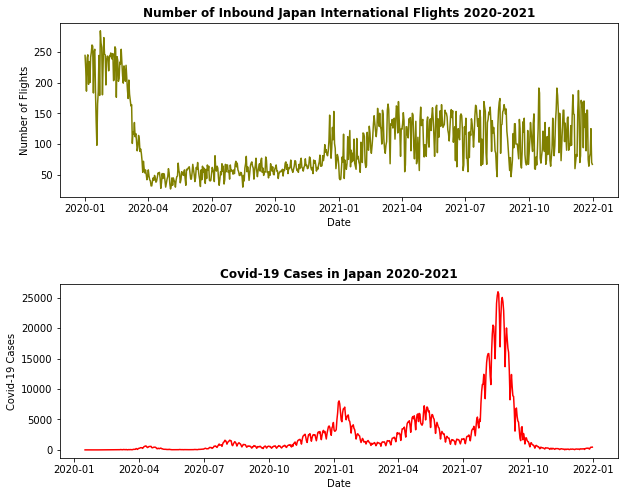

In [33]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(inbound_flight_count['day'], inbound_flight_count['callsign'], color='olive')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Flights')
ax1.set_title('Number of Inbound Japan International Flights 2020-2021', fontweight='bold')

ax2.plot(df_covid19_new['Date'], df_covid19_new['ALL'], color='red')
ax2.set_xlabel('Date')
ax2.set_ylabel('Covid-19 Cases')
ax2.set_title('Covid-19 Cases in Japan 2020-2021', fontweight='bold')

plt.subplots_adjust(hspace=0.5)
plt.show()

          callsign       ALL
callsign  1.000000  0.123428
ALL       0.123428  1.000000


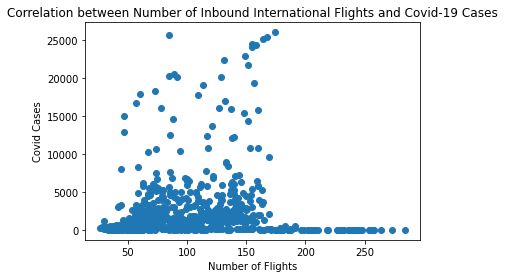

In [34]:
inbound_indexed = inbound_flight_count.set_index('day')
dfcombine2 = inbound_indexed.join(covid_indexed).dropna()
print(dfcombine2.corr())

plt.scatter(dfcombine2['callsign'], dfcombine2['ALL'])
plt.xlabel('Number of Flights')
plt.ylabel('Covid Cases')
plt.title('Correlation between Number of Inbound International Flights and Covid-19 Cases')
plt.show()

## Domestic Flights vs. Covid-19 Cases

In [35]:
domestic_flight_count = dfjapan2_domestic.groupBy('day').count() \
    .withColumnRenamed('count', 'callsign') \
    .orderBy('day') \
    .toPandas()
domestic_flight_count['day'] = pd.to_datetime(domestic_flight_count['day'])
domestic_flight_count

,day,callsign
0,2020-01-01,304
1,2020-01-02,291
2,2020-01-03,262
3,2020-01-04,314
4,2020-01-05,302
...,...,...
723,2021-12-27,613
724,2021-12-28,628
725,2021-12-29,753
726,2021-12-30,629


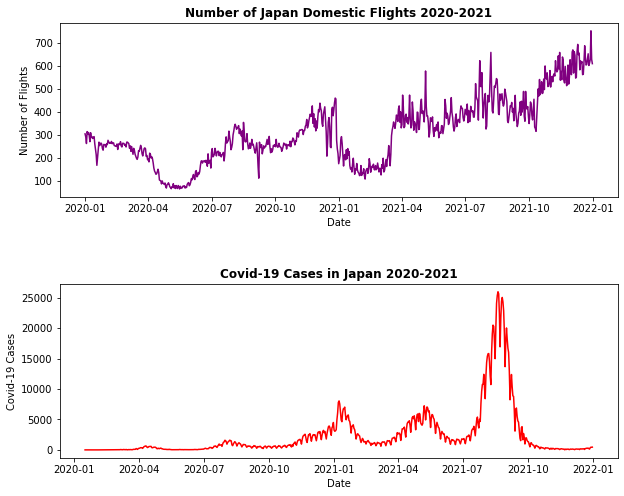

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(domestic_flight_count['day'], domestic_flight_count['callsign'], color='purple')
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Flights')
ax1.set_title('Number of Japan Domestic Flights 2020-2021', fontweight='bold')

ax2.plot(df_covid19_new['Date'], df_covid19_new['ALL'], color='red')
ax2.set_xlabel('Date')
ax2.set_ylabel('Covid-19 Cases')
ax2.set_title('Covid-19 Cases in Japan 2020-2021', fontweight='bold')

plt.subplots_adjust(hspace=0.5)
plt.show()

          callsign       ALL
callsign  1.000000  0.260097
ALL       0.260097  1.000000


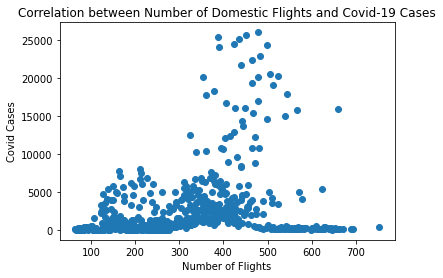

In [37]:
domestic_indexed = domestic_flight_count.set_index('day')
dfcombine3 = domestic_indexed.join(covid_indexed).dropna()
print(dfcombine3.corr())

plt.scatter(dfcombine3['callsign'], dfcombine3['ALL'])
plt.xlabel('Number of Flights')
plt.ylabel('Covid Cases')
plt.title('Correlation between Number of Domestic Flights and Covid-19 Cases')
plt.show()